In [1]:
%load_ext autoreload
%autoreload 2
from input import q,r
import numpy as np
import matplotlib.pyplot as plt
from utils.io import load_dict
from visualization.pp import plot_chi, plot_parameters

import scienceplots
plt.style.use(['science'])
plt.rcParams['figure.dpi'] = 300

parameters=load_dict('parameters-delta_chi')
#parameters2=load_dict('parameters_best')

In [8]:
parameters.keys()

dict_keys(['model', 10.0, 9.75, 9.5, 9.25, 9.0, 8.75, 8.5, 8.25, 8.0, 7.75, 7.5, 7.25, 7.0, 6.75, 6.5, 6.25, 6.0, 5.75, 5.5, 5.25, 5.0, 4.75, 4.5, 4.25, 4.0, 3.75, 3.5, 3.25, 3.0, 2.75, 2.5, 2.25, 2.0, 1.75, 1.5, 1.25, 1.0, 0.75, 0.5, 0.25])

In [136]:
def get_parameters(params_dict):
    from utils.physics import canon_cos_phase
    from visualization.pp import get_constraints
    keys = list(params_dict.keys())
    rsl = [k for k in keys if isinstance(k, float)]
    rsl.sort()
    rsl = rsl[7:]
    all_coefs1=[]
    all_coefs2=[]
    for j in range(3):
        coef1l = []
        coef2l = []

        for rs_i in range(len(rsl)):
            rs = rsl[rs_i]
            mode1 = params_dict[rs][0:3]
            mode2 = params_dict[rs][3:6]
            coef1, coef2 = mode1[j], mode2[j]
            if j == 2:
                #coef1l.append(canon_cos_phase(np.mod(coef1, 2 * np.pi)))
                #coef2l.append(canon_cos_phase(np.mod(coef2, 2 * np.pi)))
                coef1l.append(coef1)
                coef2l.append(coef2)
            else:
                coef1l.append(coef1)
                coef2l.append(coef2)
        all_coefs1.append(coef1l)
        all_coefs2.append(coef2l)

    B0l, B1l = get_constraints(params_dict, rsl)

    return all_coefs1[0], all_coefs1[1], all_coefs1[2], B0l, all_coefs2[0], all_coefs2[1], all_coefs2[2], B1l, rsl

alpha0,k0,phi0,A0,alpha1,k1,phi1,A1,rsl = get_parameters(parameters)

rs_fine=np.linspace(0.2,10,100)


# Fitting $\alpha_m$

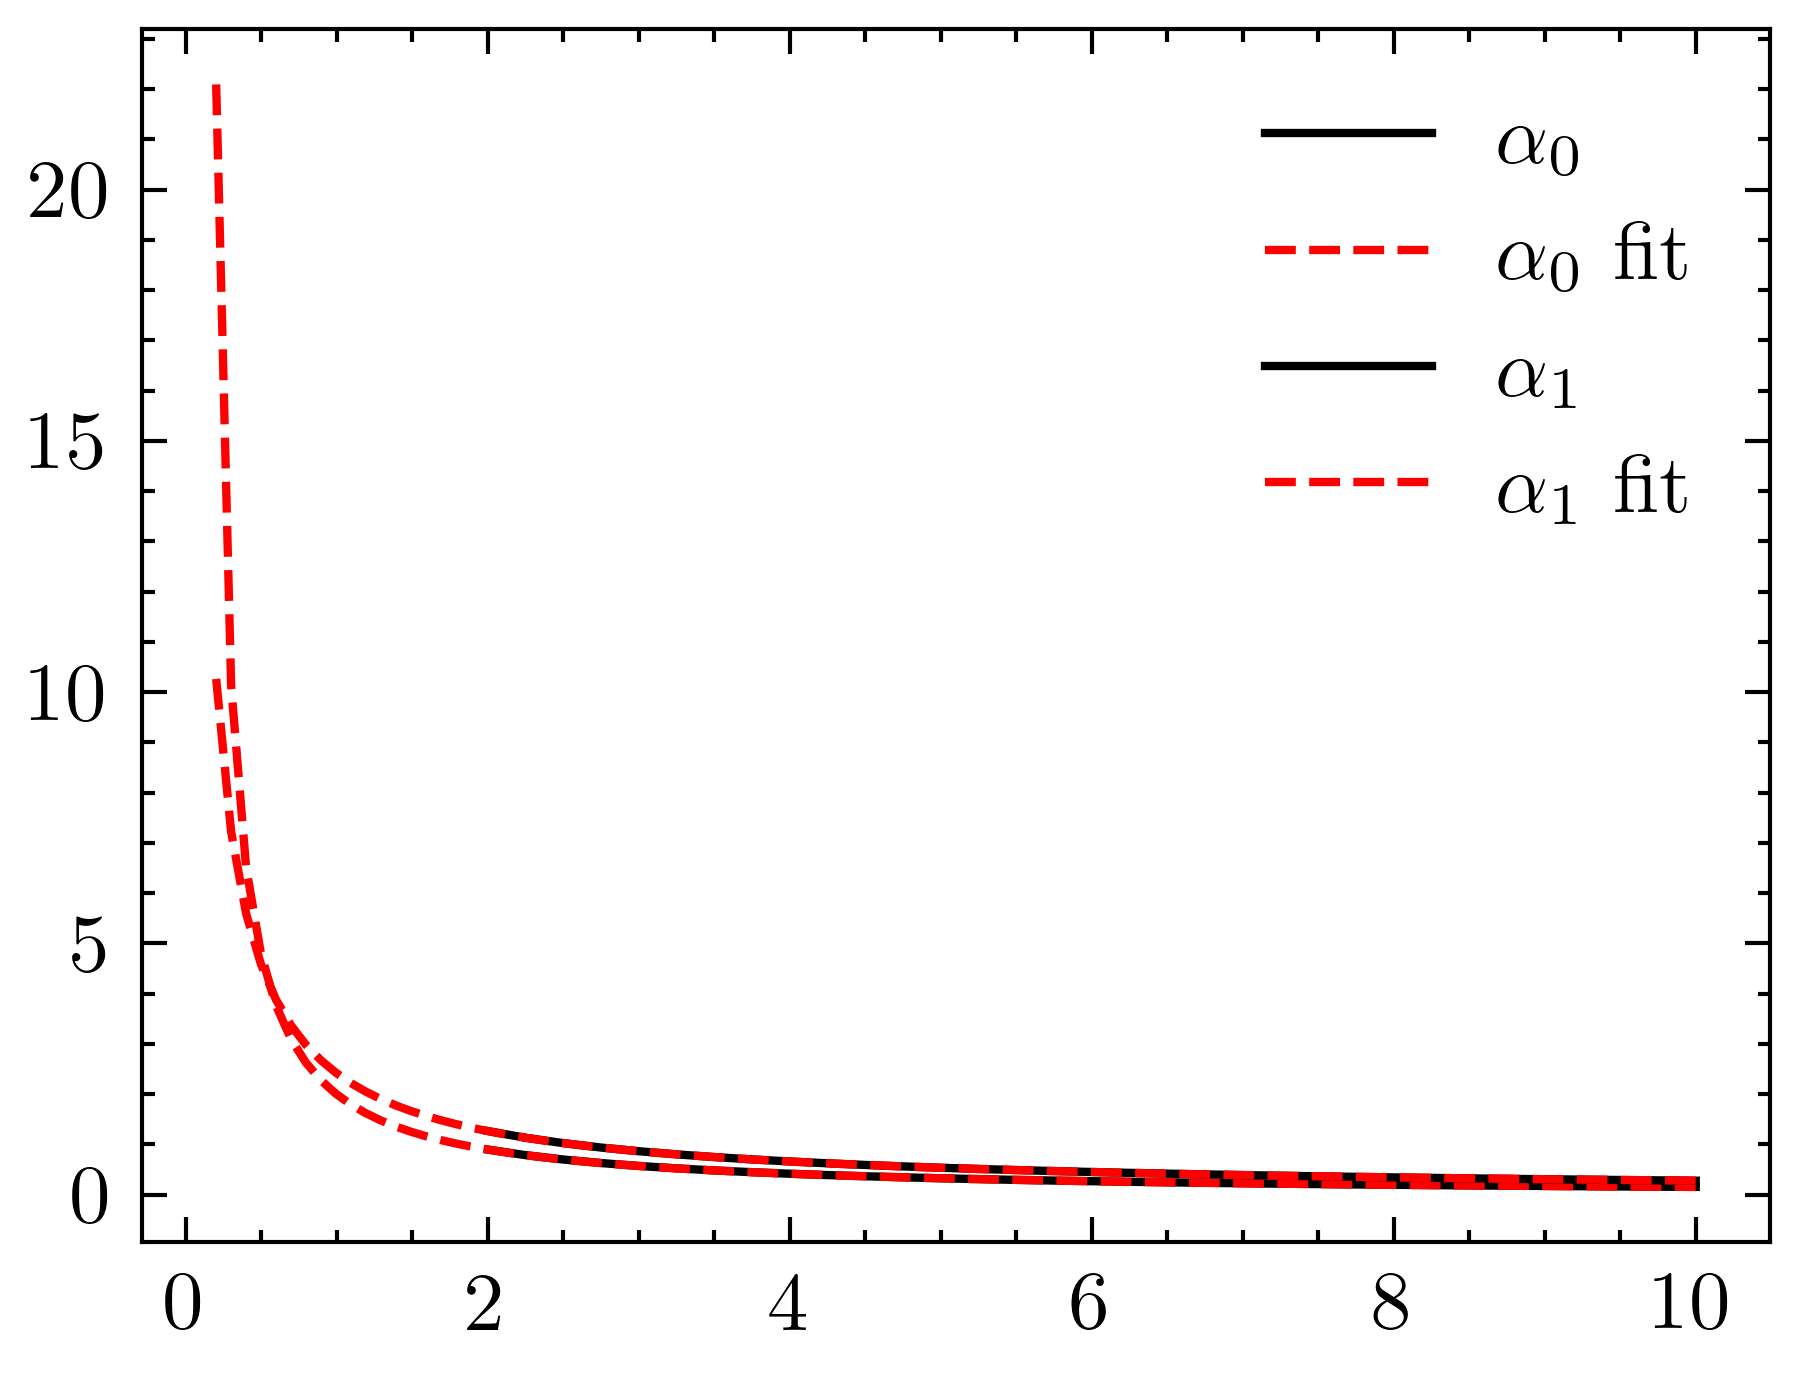

In [137]:
# alpha0,k0,phi0,A0,alpha1,k1,phi1,A1 are all smooth, decaying/converging functions. we will now fit them as a fnc of rsl. one can use an exponential, A/(rs^B+C), etc.

from scipy.optimize import curve_fit

def fit_func(rs, A, B, C):
    rs=np.array(rs)
    return A / (rs**B + C)

def fit_parameters(x_data, y_data):
    popt, pcov = curve_fit(fit_func, x_data, y_data)
    return popt

alpha0_fit_params = fit_parameters(rsl, alpha0)
alpha1_fit_params = fit_parameters(rsl, alpha1)

plt.plot(rsl,alpha0,'k', label=r"$\alpha_0$")
plt.plot(rs_fine,fit_func(rs_fine,*alpha0_fit_params), 'r--', label=r"$\alpha_0$ fit")
plt.plot(rsl,alpha1,'k', label=r"$\alpha_1$")
plt.plot(rs_fine,fit_func(rs_fine,*alpha1_fit_params), 'r--', label=r"$\alpha_1$ fit")
plt.legend()

# Fitting $k_m$

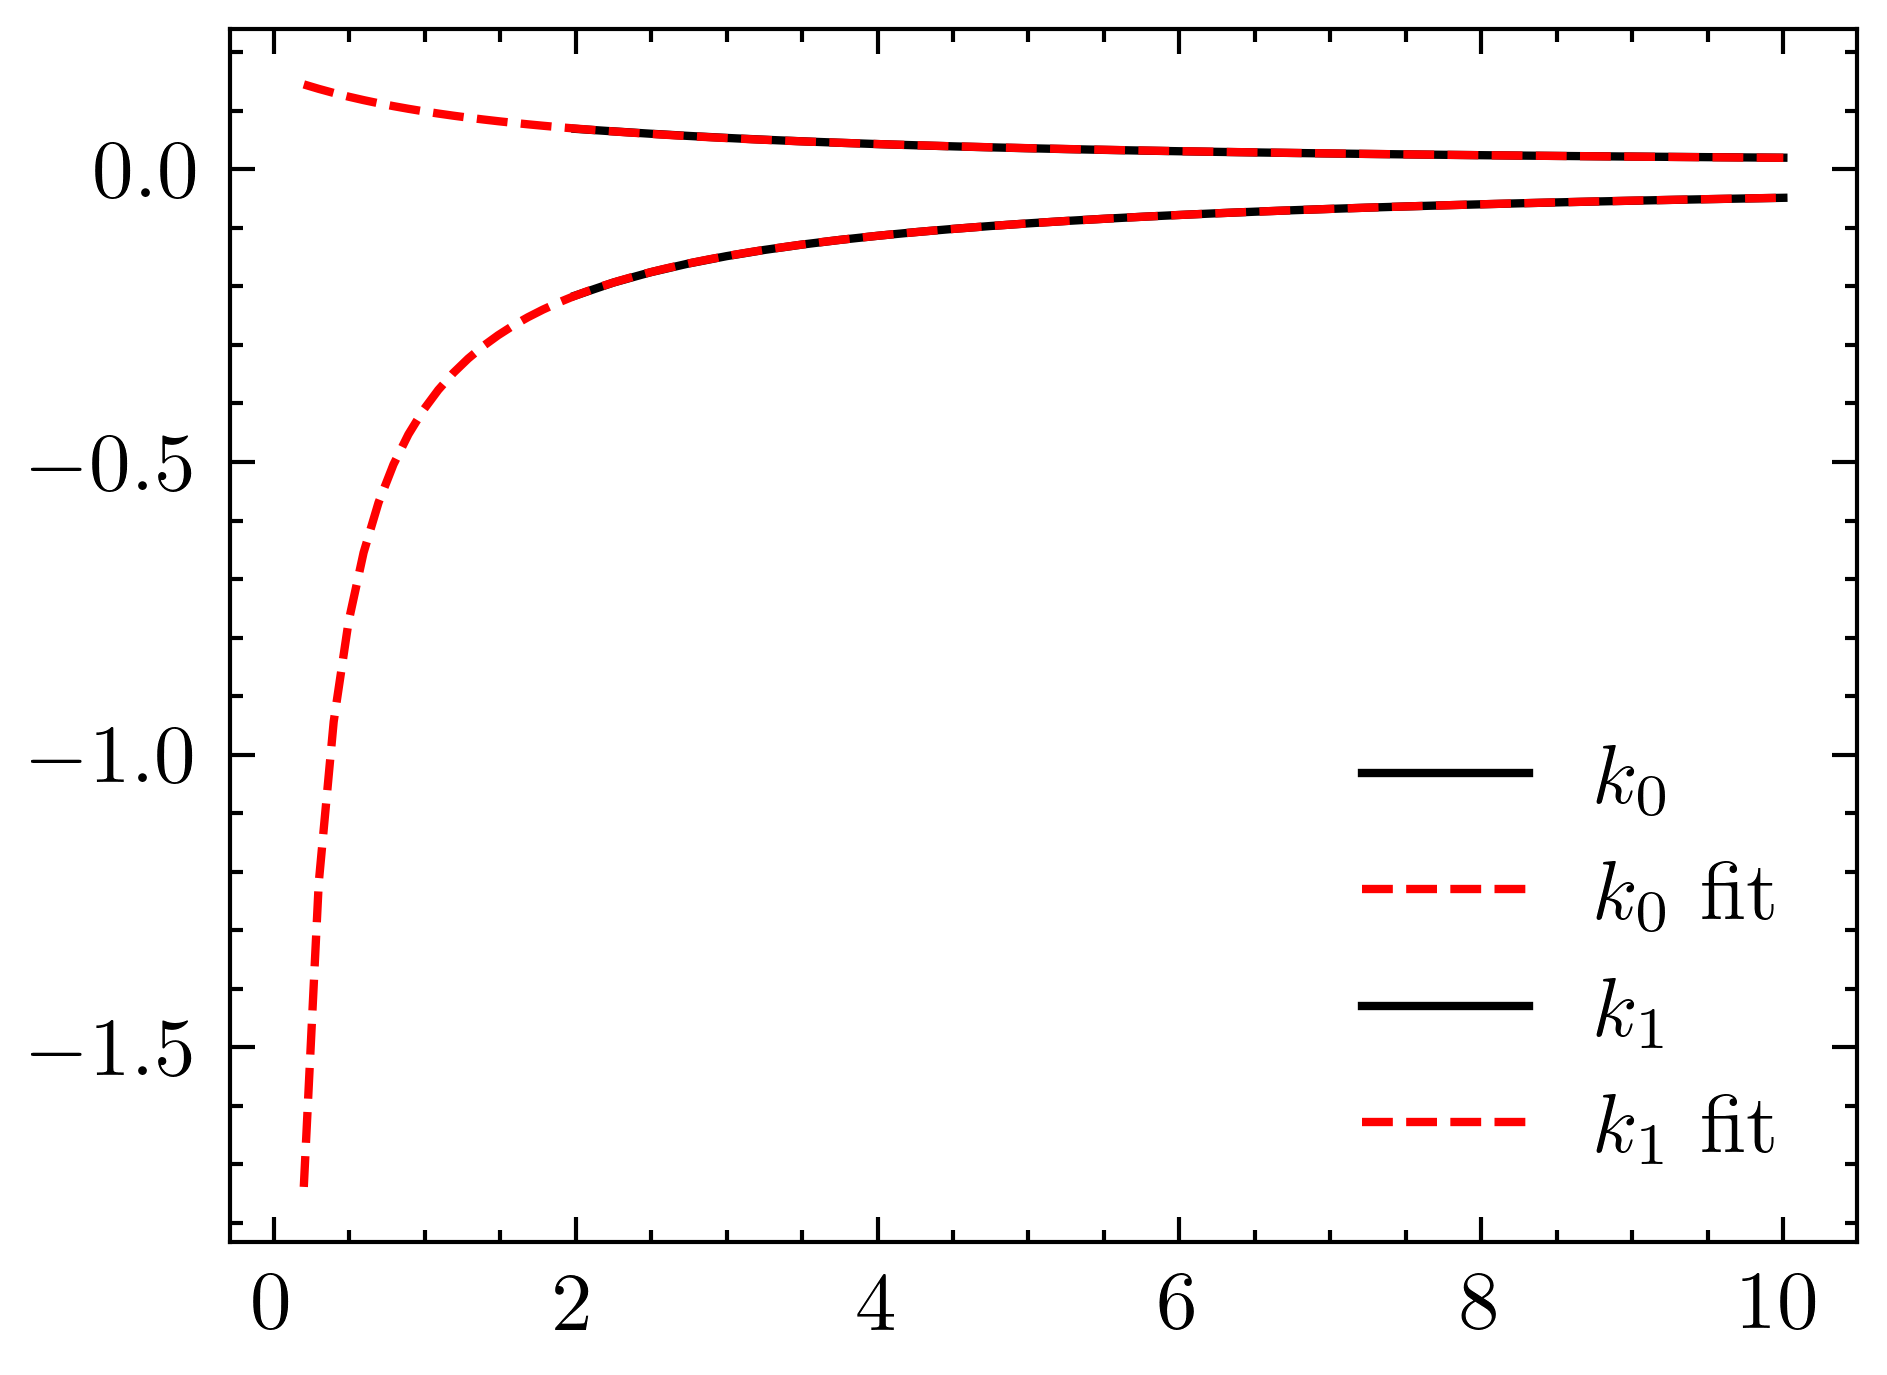

In [138]:
# alpha0,k0,phi0,A0,alpha1,k1,phi1,A1 are all smooth, decaying/converging functions. we will now fit them as a fnc of rsl. one can use an exponential, A/(rs^B+C), etc.

from scipy.optimize import curve_fit

def fit_func(rs, A, B, C):
    rs=np.array(rs)
    return A / (rs**B + C)

def fit_parameters(x_data, y_data):
    popt, pcov = curve_fit(fit_func, x_data, y_data)
    return popt

k0_fit_params = fit_parameters(rsl, k0)
k1_fit_params = fit_parameters(rsl, k1)

plt.plot(rsl,k0,'k', label=r"$k_0$")
plt.plot(rs_fine,fit_func(rs_fine,*k0_fit_params), 'r--', label=r"$k_0$ fit")
plt.plot(rsl,k1,'k', label=r"$k_1$")
plt.plot(rs_fine,fit_func(rs_fine,*k1_fit_params), 'r--', label=r"$k_1$ fit")
plt.legend()

# Fitting $\phi_m$

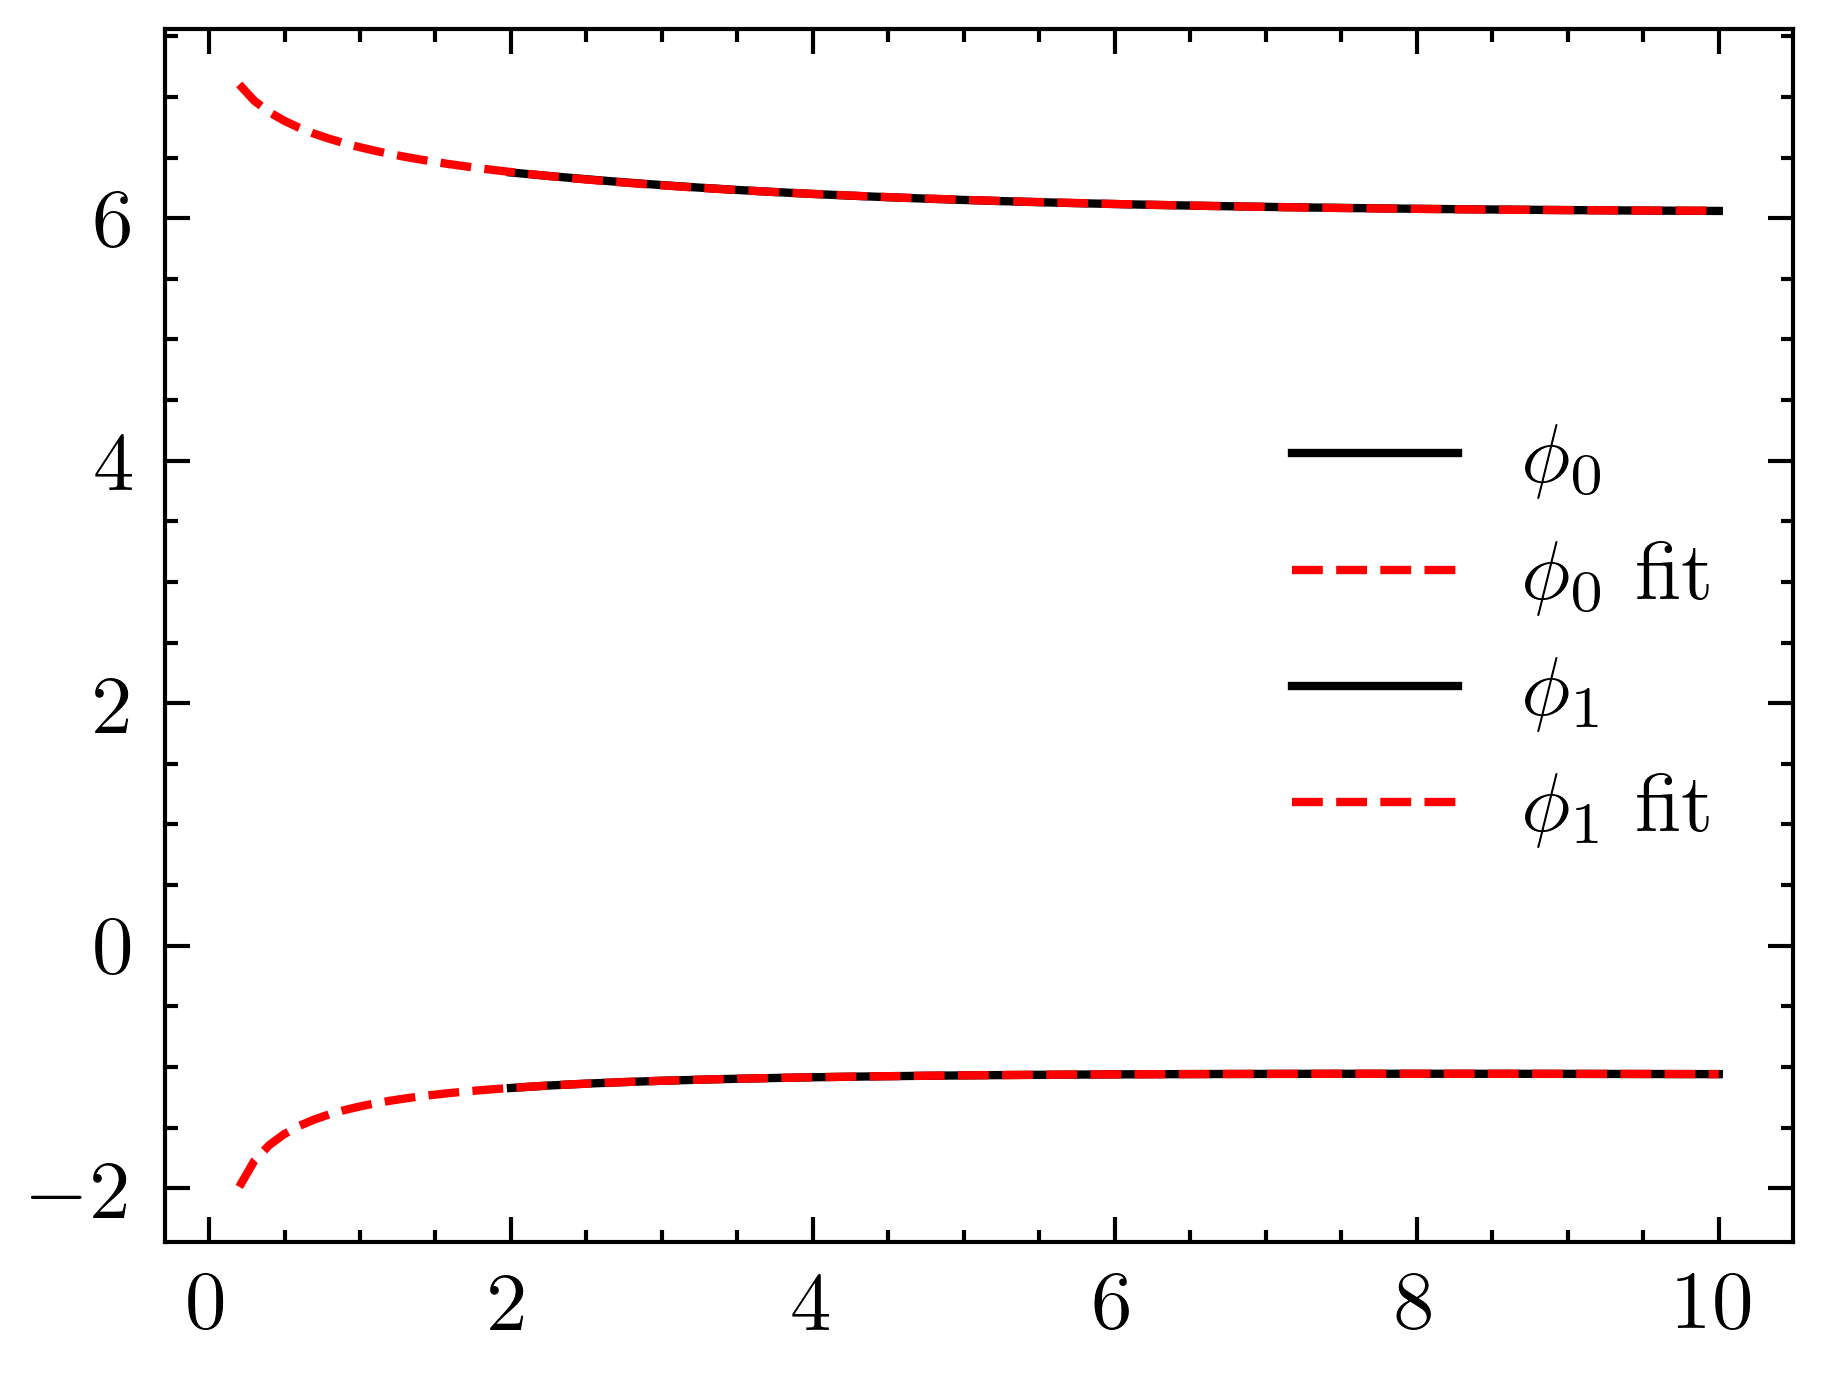

In [139]:
# phi_m are converging but has some bunps. we need to find correct form to fit them. 

from scipy.optimize import curve_fit

def fit_func(rs, A, B, C, D):
    rs=np.array(rs)
    return A*rs**B + C*rs**D

def fit_parameters(x_data, y_data):
    popt, pcov = curve_fit(fit_func, x_data, y_data,maxfev=10000)
    return popt

phi0_fit_params = fit_parameters(rsl, phi0)
phi1_fit_params = fit_parameters(rsl, phi1)

plt.plot(rsl,phi0,'k', label=r"$\phi_0$")
plt.plot(rs_fine,fit_func(rs_fine,*phi0_fit_params), 'r--', label=r"$\phi_0$ fit")
plt.plot(rsl,phi1,'k', label=r"$\phi_1$")
plt.plot(rs_fine,fit_func(rs_fine,*phi1_fit_params), 'r--', label=r"$\phi_1$ fit")
plt.legend()

# Fitting $A_m$

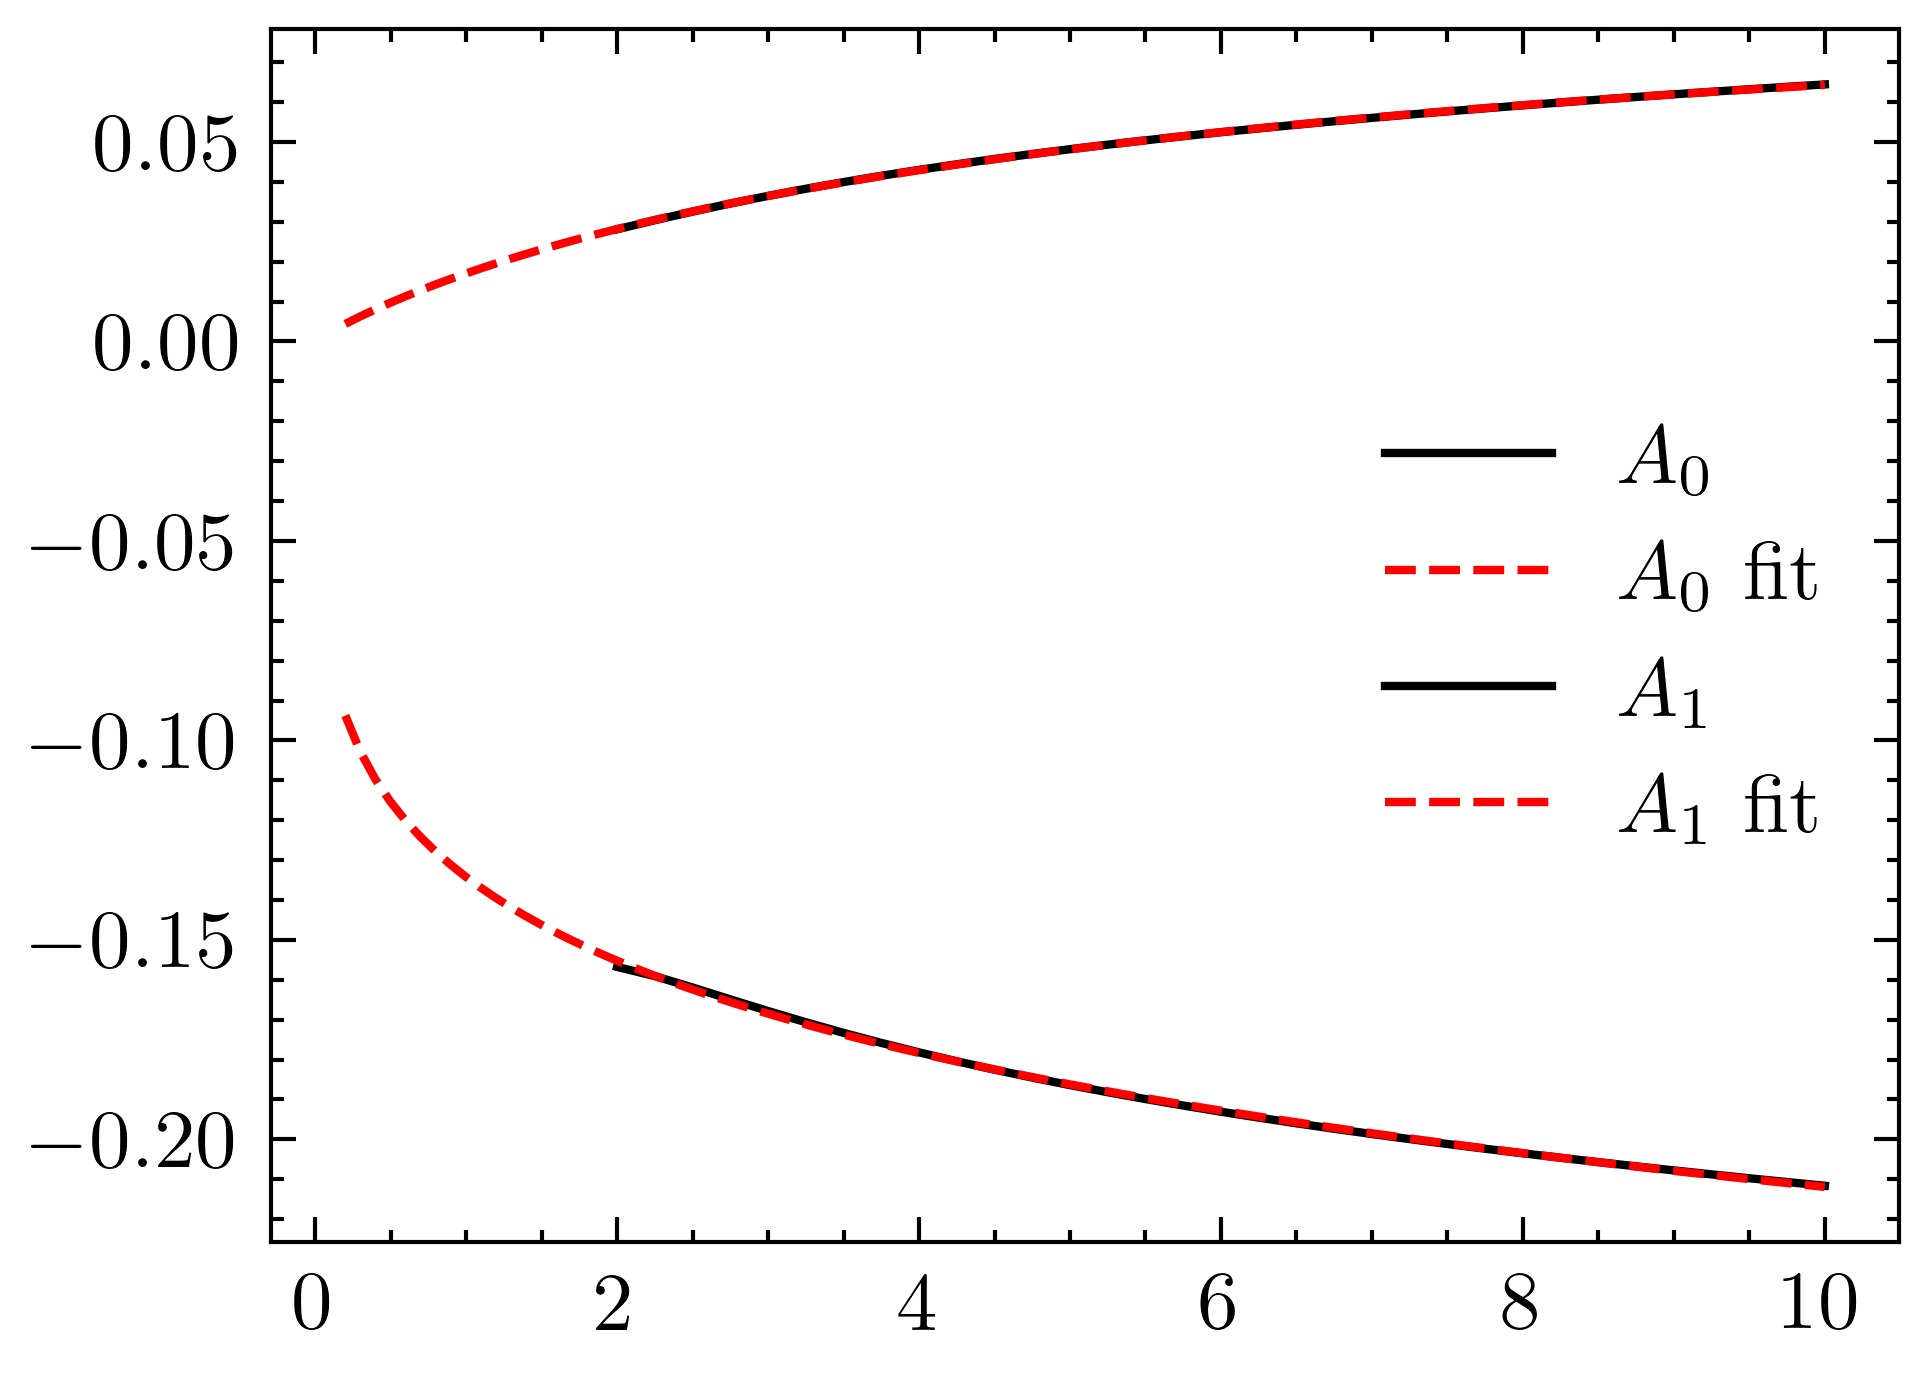

In [161]:
# alpha0,k0,phi0,A0,alpha1,k1,phi1,A1 are all smooth, decaying/converging functions. we will now fit them as a fnc of rsl. one can use an exponential, A/(rs^B+C), etc.

from scipy.optimize import curve_fit

def fit_func(rs, A, B, C):
    return A / (rs**B + C)

def fit_func2(rs, A, B, C, D):
    rs=np.array(rs)
    return A*rs**B + C*rs**D

def fit_parameters(x_data, y_data):
    popt, pcov = curve_fit(fit_func, x_data, y_data)
    return popt

A0_fit_params = fit_parameters(rsl, A0)
A1_fit_params = fit_parameters(rsl, A1)

plt.plot(rsl,A0,'k', label=r"$A_0$")
plt.plot(rs_fine,fit_func(rs_fine,*A0_fit_params), 'r--', label=r"$A_0$ fit")
plt.plot(rsl,A1,'k', label=r"$A_1$")
plt.plot(rs_fine,fit_func(rs_fine,*A1_fit_params), 'r--', label=r"$A_1$ fit")
plt.legend()

# Reporting all parameters

In [113]:
print('alpha_0: Fitted by', 'A / (rs**B + C)',f'\nA = {alpha0_fit_params[0]:.3f}, \nB = {alpha0_fit_params[1]:.3f}, \nC = {alpha0_fit_params[2]:.3f} \n')
print('alpha_1: Fitted by', 'A / (rs**B + C)',f'\nA = {alpha1_fit_params[0]:.3f}, \nB = {alpha1_fit_params[1]:.3f}, \nC = {alpha1_fit_params[2]:.3f} \n')
print('k_0: Fitted by', 'A / (rs**B + C)',f'\nA = {k0_fit_params[0]:.3f}, \nB = {k0_fit_params[1]:.3f}, \nC = {k0_fit_params[2]:.3f} \n')
print('k_1: Fitted by', 'A / (rs**B + C)',f'\nA = {k1_fit_params[0]:.3f}, \nB = {k1_fit_params[1]:.3f}, \nC = {k1_fit_params[2]:.3f} \n')


alpha_0: Fitted by A / (rs**B + C) 
A = 1.798, 
B = 1.073, 
C = -0.097 

alpha_1: Fitted by A / (rs**B + C) 
A = 2.464, 
B = 0.947, 
C = 0.022 

k_0: Fitted by A / (rs**B + C) 
A = -0.414, 
B = 0.930, 
C = 0.014 

k_1: Fitted by A / (rs**B + C) 
A = 0.253, 
B = 1.053, 
C = 1.563 



In [117]:
print('phi_0: Fitted by', 'A*rs**B + C*rs**D',f'\nA = {phi0_fit_params[0]:.3f}, \nB = {phi0_fit_params[1]:.3f}, \nC = {phi0_fit_params[2]:.3f}, \nD = {phi0_fit_params[3]:.3f} \n')
print('phi_1: Fitted by', 'A*rs**B + C*rs**D',f'\nA = {phi1_fit_params[0]:.3f}, \nB = {phi1_fit_params[1]:.3f}, \nC = {phi1_fit_params[2]:.3f}, \nD = {phi1_fit_params[3]:.3f} \n')
print('A_0: Fitted by', 'A / (rs**B + C)',f'\nA = {A0_fit_params[0]:.3f}, \nB = {A0_fit_params[1]:.3f}, \nC = {A0_fit_params[2]:.3f} \n')
print('A_1: Fitted by', 'A / (rs**B + C)',f'\nA = {A1_fit_params[0]:.3f}, \nB = {A1_fit_params[1]:.3f}, \nC = {A1_fit_params[2]:.3f} \n')

phi_0: Fitted by A*rs**B + C*rs**D 
A = 6.580, 
B = -0.047, 
C = 0.005, 
D = 1.554 

phi_1: Fitted by A*rs**B + C*rs**D 
A = 0.775, 
B = -0.057, 
C = -1.963, 
D = -0.057 

A_0: Fitted by A / (rs**B + C) 
A = 0.020, 
B = -0.926, 
C = 0.200 

A_1: Fitted by A / (rs**B + C) 
A = -0.170, 
B = -0.271, 
C = 0.266 



# Testing

In [155]:
chiq/chiq_RPA**2

array([-1.25669732e+05, -3.14219525e+04, -1.39686602e+04, ...,
       -2.61821384e+09, -2.61845257e+09, -2.61767423e+09])

0.1919158292677513


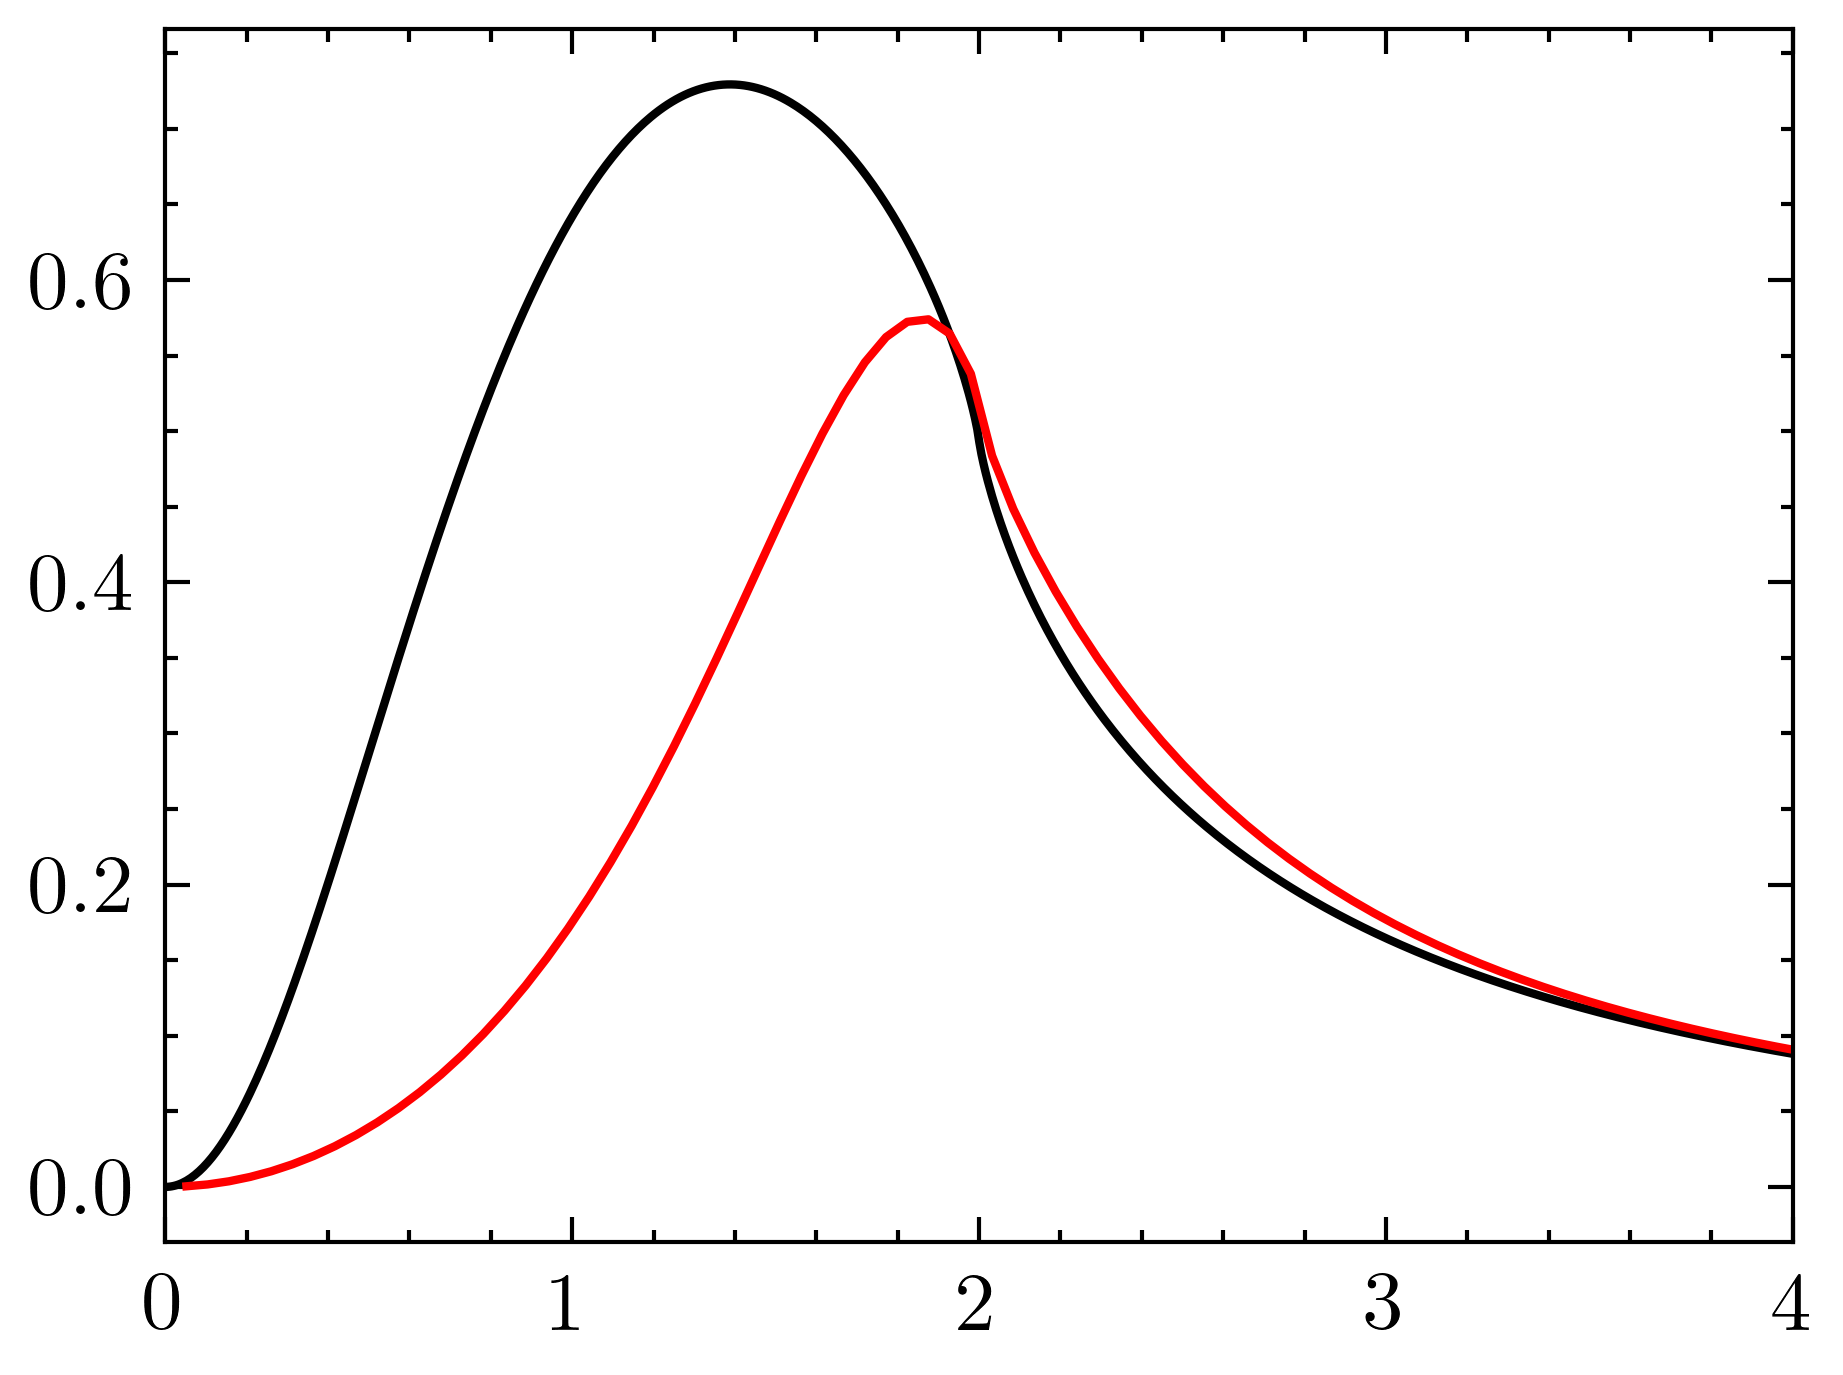

In [160]:
from optimization.production import get_chi_interp
from utils.fourier import chi_q_from_chi_r_fast
from utils.physics import canon_cos_phase
from utils.utils_chi import chi00q, corradini_pz, get_chi, get_gas_params

rs=1
kF,n0,NF = get_gas_params(rs)
fxc = corradini_pz(rs, q)
vc = 4 * np.pi / q**2

chi0q = chi00q(q, rs)
chiq_RPA = chi0q / (1 - chi0q * (vc))
chiq = chi0q / (1 - chi0q * (vc+fxc))

#plt.plot(q/kF, -chiq_RPA/NF, 'k-.', label=r'$\chi^{RPA}(q)$')
plt.plot(q/kF, -chiq/NF, 'k-', label=r'$\chi(q)$')

rs=10
kF,n0,NF = get_gas_params(rs)
fxc = corradini_pz(rs, q)
vc = 4 * np.pi / q**2

chi0q = chi00q(q, rs)
chiq_RPA = chi0q / (1 - chi0q * (vc))
chiq = chi0q / (1 - chi0q * (vc+fxc))

#plt.plot(q/kF, -chiq_RPA/NF, 'k-.', label=r'$\chi^{RPA}(q)$')
plt.plot(q/kF, -chiq/NF, 'r-', label=r'$\chi(q)$')
#plt.plot(q/kF, chiq/chiq_RPA, 'k-', label=r'$\chi(q)$')
plt.xlim(0,4)
print(kF)

In [ ]:
from optimization.production import get_chi_interp
from utils.fourier import chi_q_from_chi_r_fast
from utils.physics import canon_cos_phase
from utils.utils_chi import chi00q, corradini_pz, get_chi, get_gas_params


def get_chi_interpolated(rs):
    from optimization.production import chi_interp
    from optimization.models import delta_chi
    alpha0 = 1.798 / (rs**1.073 - 0.097) 
    alpha1 = 2.464 / (rs**0.947 + 0.022)

    k0 = -0.414 / (rs**0.930 + 0.014)
    k1 = 0.253 / (rs**1.053 + 1.563)

    phi0 = 6.580*rs**(-0.047) + 0.005*rs**(1.554)
    phi1 = 0.775*rs**(-0.057) - 1.963*rs**(-0.057)

    A0 = 0.020 / (rs**(-0.926) + 0.200)
    A1 = -0.170 / (rs**(-0.271) + 0.266)

    params = [alpha0, k0, phi0,alpha1, k1, phi1]
    delta_chi_interpolated = delta_chi(r,rs,params)
    chi_interpolated = chi_interp(q, delta_chi_interpolated, rs)
    return chi_interpolated

def plot_chi_from_interpolation(r, q, rs, error=False):
    from matplotlib.ticker import ScalarFormatter

    kF, n0, NF = get_gas_params(rs)
    chiR = get_chi(q, rs)
    chi_interpp = get_chi_interpolated(rs)
    dr = r[1] - r[0]
    font_size = 8

    fig, ax = plt.subplots(nrows=2, ncols=1)

    fxc = corradini_pz(rs, q)
    vc = 4 * np.pi / q**2

    chi0q = chi00q(q, rs)
    chiq = chi0q / (1 - chi0q * (vc + fxc))

    FT_q, FT_chiq = chi_q_from_chi_r_fast(r, chi_interpp, qlist=None)

    if error:
        # ax[0].plot(kF*r[::10],chiR[::10]/NF,'k-',label=r'$\chi^h(r)$')
        ax[0].plot(
            kF * r[100::180],
            (chiR - chi_interpp)[100::180] / (2 * kF**4 / np.pi**3),
            "k-",
            markersize=1,
            label=r"$\chi_{M=2}^{h,\mathrm{interp.}}(r)$",
        )
        # ax[0].plot(kF*r[::180],np.abs((chiR-chi_interp)/chiR)[::180]*100,'ro',markersize=1,label=r'$\chi_{M=2}^{h,\mathrm{interp.}}(r)$')
        ax[0].plot(kF * r, 0 * kF * r, "k", lw=0.25)
        lim_upper = 0.0002  # max(chiR/(2*kF**4/pi**3))*.2
        ax[0].set_ylim(-lim_upper / 1, lim_upper)
        ax[0].set_xlim(0, 24)
        ax[0].set_xlabel(r"$k_F r$", fontsize=font_size, labelpad=2)
        ax[0].set_ylabel(r"$\Delta\chi(r)/6\pi n_0 N_\mathrm{F}$", fontsize=font_size)
        # ax[0].set_title(fr'$r_s = {rs}$',fontsize=font_size)

        # ax[1].plot(FT_q/kF,-np.abs(FT_chiq-chiq)/chiq*100,'r-.',label=r' $\chi^0(q)$ invFT',lw=1)
        ax[1].plot(FT_q / kF, (chiq - FT_chiq) / NF, "k-", lw=1)

        # error_qmc = 0.2577 / 2
        limy = max(abs(chiq - FT_chiq) / NF) * 1.2  # error_qmc*2
        # plt.axhspan(-error_qmc,error_qmc, xmax=10,color='grey', alpha=0.3)
        ax[1].set_ylim(-limy, limy)
        ax[1].plot(FT_q / kF, 0 * FT_q, "k", lw=0.25)
        # ax[1].set_ylim(0,10)
        ax[1].set_xlim(0, 10)
        ax[1].set_xlabel(r"$q/k_F$", fontsize=font_size, labelpad=2)
        ax[1].set_ylabel(r"$\Delta\chi(q)/N_\mathrm{F}$", fontsize=font_size)
        # ax[1].set_title(fr'$r_s = {rs}$')
        # ax[1].legend(fontsize=font_size)
    else:
        ax[0].plot(
            kF * r[::10], chiR[::10] / (2 * kF**4 / np.pi**3), "k-", label=r"$\chi^h(r)$"
        )
        ax[0].plot(
            kF * r[::180],
            chi_interpp[::180] / (2 * kF**4 / np.pi**3),
            "r-.",
            markersize=1,
            label=r"$\chi_{M=2}^{h,\mathrm{interp.}}(r)$",
        )
        ax[0].plot(kF * r, 0 * kF * r, "k", lw=0.5)
        lim_upper = max(chiR / (2 * kF**4 / np.pi**3)) * 1.2
        ax[0].set_ylim(-lim_upper / 1, lim_upper)
        ax[0].set_xlim(0, 12)
        ax[0].set_xlabel(r"$k_F r$", fontsize=font_size, labelpad=2)
        ax[0].set_ylabel(r"$\chi(r)/6\pi n_0 N_\mathrm{F}$", fontsize=font_size)
        # ax[0].set_title(fr'$r_s = {rs}$',fontsize=font_size)
        ax[0].legend(loc="lower right", fontsize=font_size)
        ax[0].tick_params(axis="both", labelsize=font_size)
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((-1, -1))  # force ×10^{-1}

        ax[0].yaxis.set_major_formatter(formatter)
        ax[0].ticklabel_format(axis="y", style="sci", scilimits=(-1, -1))

        ax[1].plot(q / kF, -chiq / NF, "k", label=r" $\chi(q)$ analytical", lw=1)
        ax[1].plot(FT_q / kF, -FT_chiq / NF, "r-.", label=r" $\chi(q)$ invFT", lw=1)
        ax[1].set_xlim(0, 10)
        ax[1].set_xlabel(r"$q/k_F$", fontsize=font_size, labelpad=2)
        ax[1].set_ylabel(r"$-\chi(q)/N_\mathrm{F}$", fontsize=font_size)
        # ax[1].set_title(fr'$r_s = {rs}$')
        ax[1].legend(fontsize=font_size)
        ax[1].tick_params(axis="both", labelsize=font_size)

    print(f"∫chi(r)r^2dr: {np.sum(chi_interpp * r**2) * dr:.6f}")
    # fig.subplots_adjust(hspace=1.4)
    fig.subplots_adjust(hspace=0.35, left=0.15, right=0.95, top=0.92, bottom=0.12)

    

∫chi(r)r^2dr: -0.000016


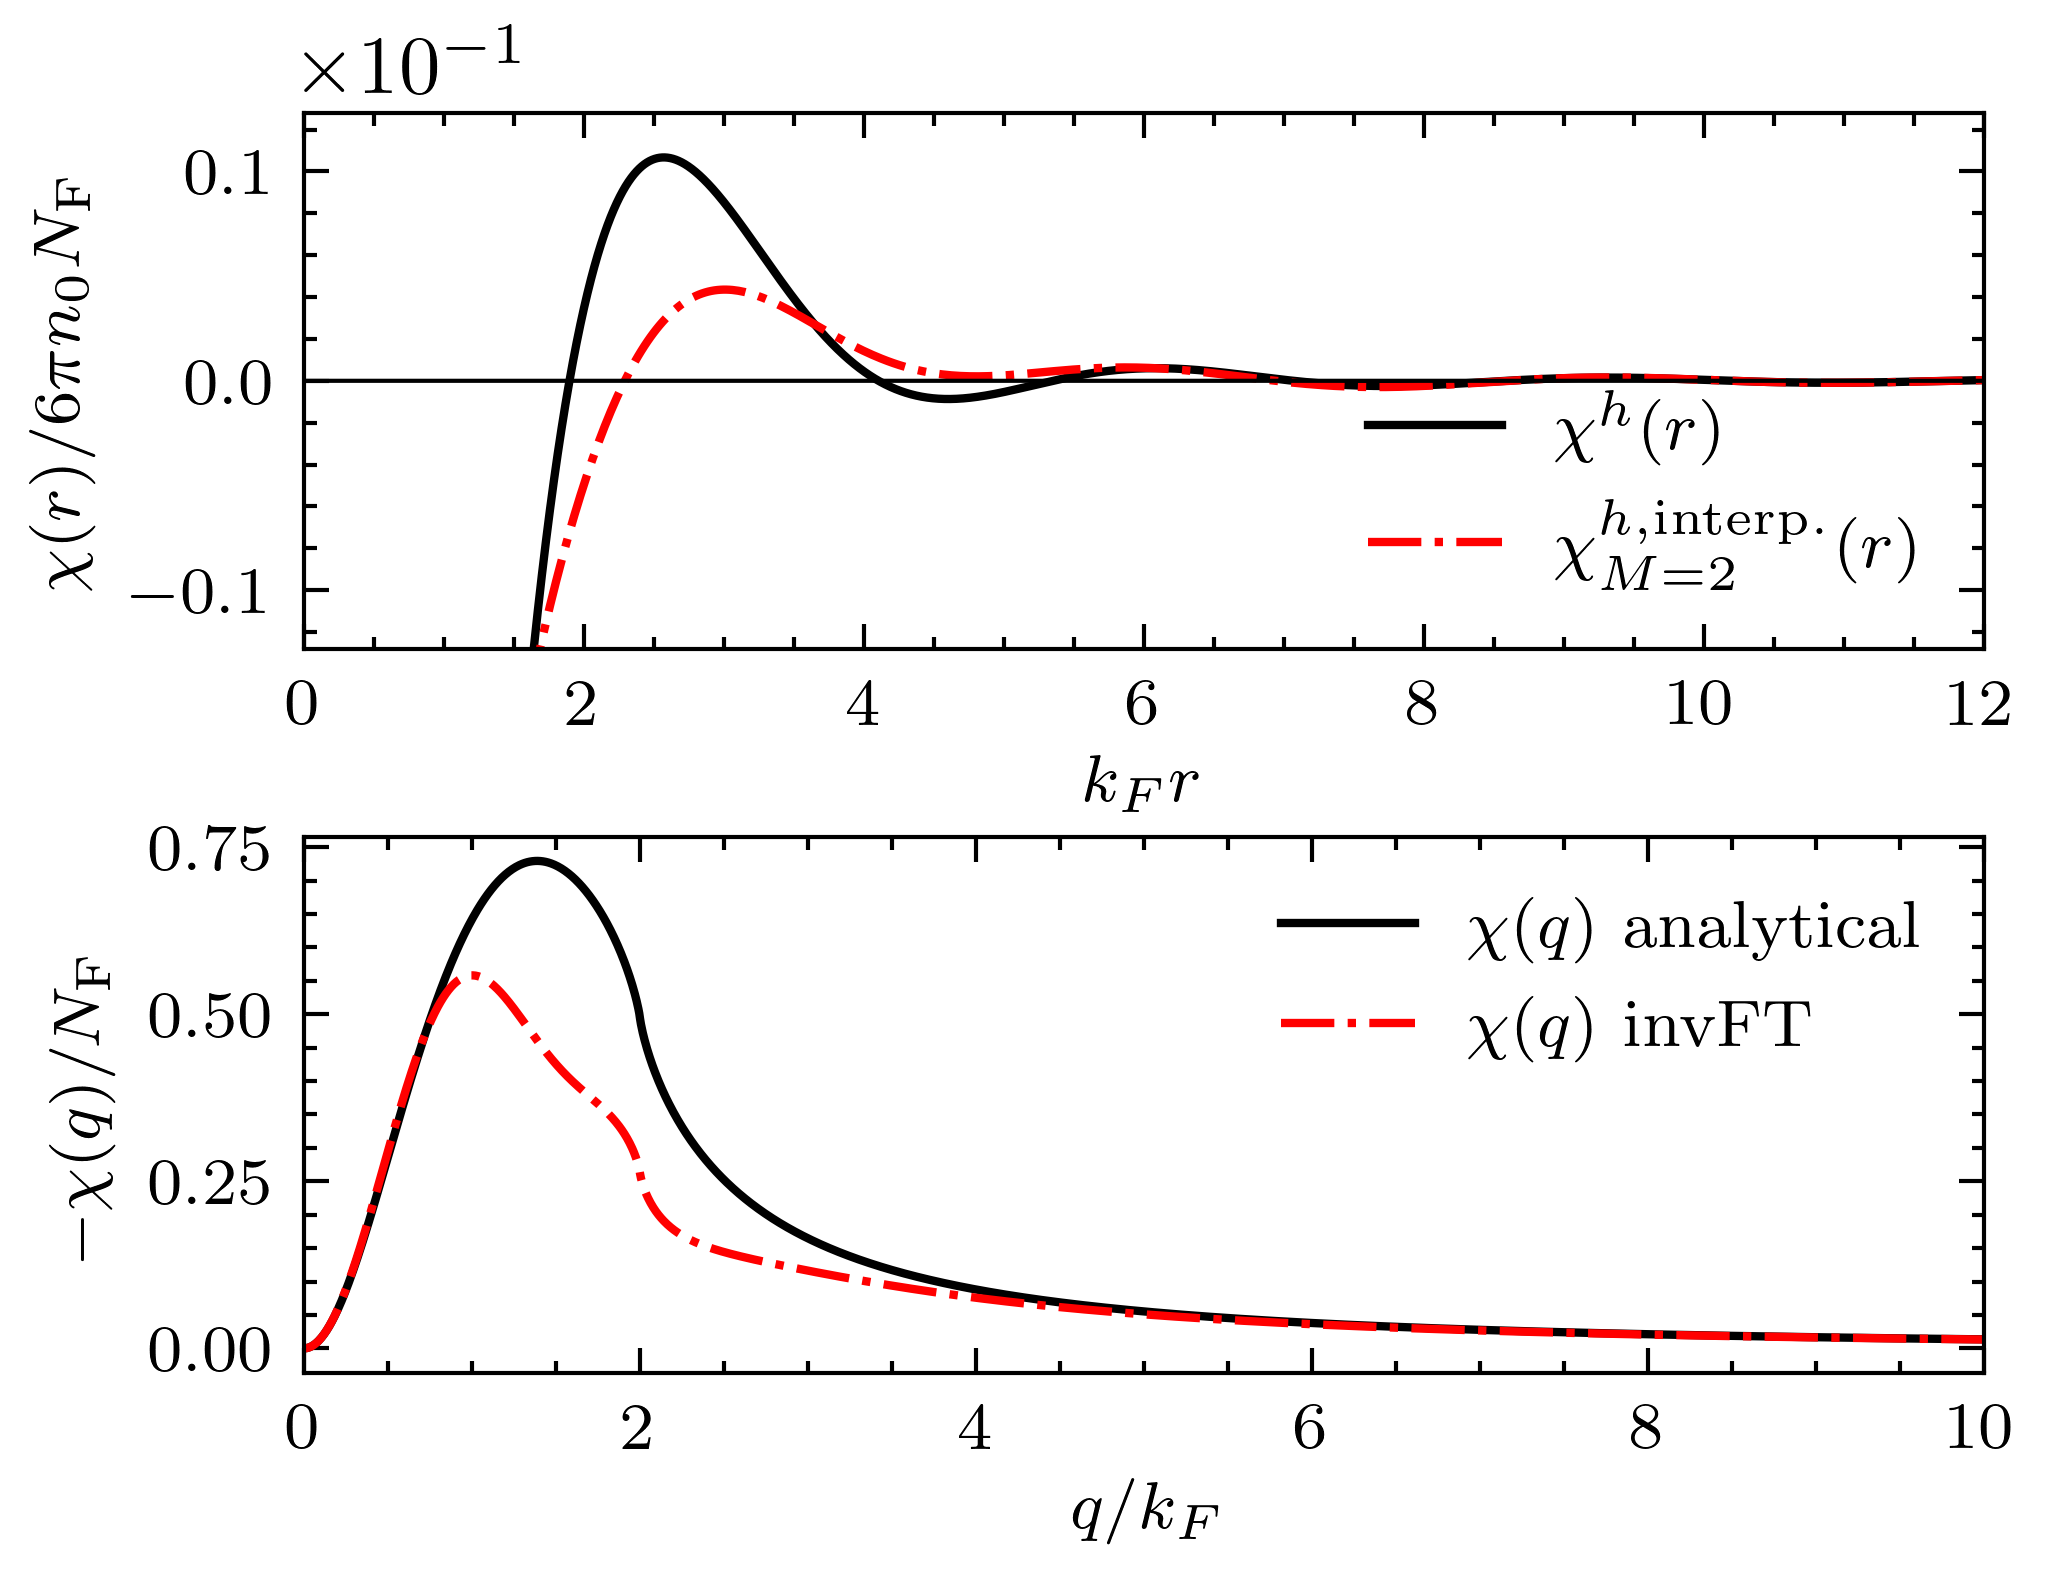

In [ ]:
rs=1
plot_chi(r, q, rs, error=False)